In [ ]:
import pandas as pd
import numpy as np
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

In [ ]:
data = {
    "Temperatur": [10, 25, 18, 20, 18, 20, 22, 24],
    "Kecepatan_Angin": [0, 0, 5, 3, 7, 10, 5, 6],
    "Label": ["Dingin", "Panas", "Dingin", "Panas", "Dingin", "Dingin", "Panas", "Panas"]
}

df = pd.DataFrame(data)
print("Dataset:")
print(df)

X = df[["Temperatur", "Kecepatan_Angin"]]
y = df["Label"]

Dataset:
   Temperatur  Kecepatan_Angin   Label
0          10                0  Dingin
1          25                0   Panas
2          18                5  Dingin
3          20                3   Panas
4          18                7  Dingin
5          20               10  Dingin
6          22                5   Panas
7          24                6   Panas


In [ ]:
print("\nMissing Values per Kolom:")
print(df.isnull().sum())


Missing Values per Kolom:
Temperatur         0
Kecepatan_Angin    0
Label              0
dtype: int64


In [ ]:
df["Label"] = df["Label"].map({"Dingin": 0, "Panas": 1})

print("\nDataset Setelah Encoding:")
print(df)


Dataset Setelah Encoding:
   Temperatur  Kecepatan_Angin  Label
0          10                0      0
1          25                0      1
2          18                5      0
3          20                3      1
4          18                7      0
5          20               10      0
6          22                5      1
7          24                6      1


In [ ]:
X = df[["Temperatur", "Kecepatan_Angin"]]
y = df["Label"]

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

sc = StandardScaler()
x_train_scaled = sc.fit_transform(x_train)
x_test_scaled = sc.transform(x_test)


In [ ]:
nb = GaussianNB()
nb.fit(x_train_scaled, y_train)

GaussianNB()

In [ ]:
from sklearn.metrics import accuracy_score

#evaluasi
y_pred = nb.predict(x_test_scaled)

print("\nAkurasi Model :", accuracy_score(y_test, y_pred))


Akurasi Model : 0.5



Confusion Matrix:
[[1 0]
 [1 0]]


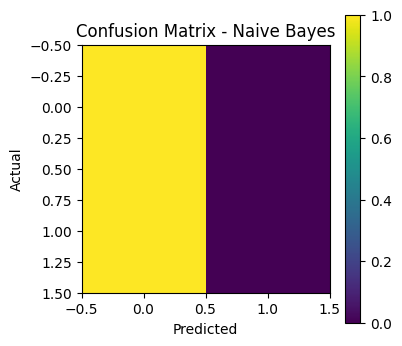

In [ ]:
#cofusion matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(4,4))
plt.imshow(cm)
plt.title("Confusion Matrix - Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()


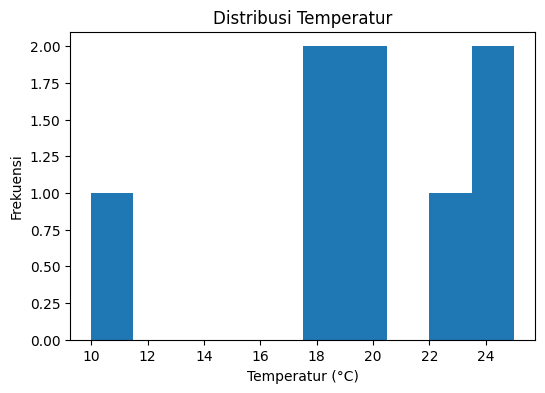

In [ ]:
#distribusi
plt.figure(figsize=(6,4))
plt.hist(df["Temperatur"])
plt.title("Distribusi Temperatur")
plt.xlabel("Temperatur (°C)")
plt.ylabel("Frekuensi")
plt.show()

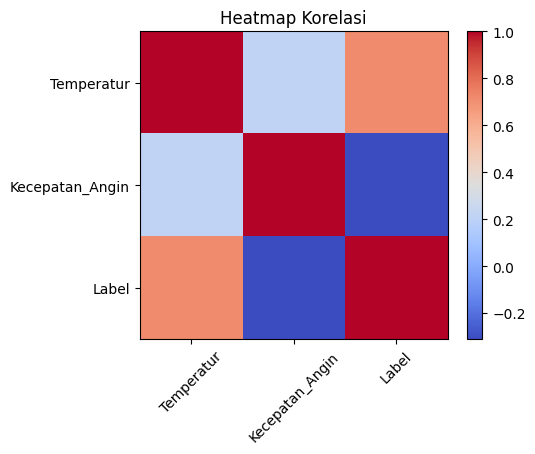

In [ ]:
#heatmap
corr = df.corr()

plt.figure(figsize=(5,4))
plt.imshow(corr, cmap="coolwarm")
plt.title("Heatmap Korelasi")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.show()

In [18]:
#prediksi
m_scaled = sc.transform([[16, 3]])
pred_mary = nb.predict(m_scaled)

print("\nPrediksi Mary (16°C, angin 3 km/jam):")
print("Dingin" if pred_mary[0] == 0 else "Panas")


Prediksi Mary (16°C, angin 3 km/jam):
Dingin


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [20]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

# Buat model KNN
best_knn = KNeighborsClassifier(n_neighbors=3)
best_knn.fit(X, y)

# Karena data kecil, gunakan cv=2 agar tidak error
cv_scores = cross_val_score(best_knn, X, y, cv=2)

print("Cross Validation Accuracy:", cv_scores.mean())
print("Std Dev:", cv_scores.std())


Cross Validation Accuracy: 0.75
Std Dev: 0.25
